**Conditional Variational Autoencoder (CVAE)** trained with the **ELBO** (reconstruction + KL) objective.

### How it works (quick notes)

* **Conditioning**: we one-hot encode the label `c` and concatenate it to the image vector for both encoder (`[x, c]`) and decoder (`[z, c]`).
* **Reparameterization**: `z = μ + σ ⊙ ε`, with `ε ~ N(0, I)`.
* **ELBO**: `loss = MSE(x_logits, x) + β * KL(q(z|x,c) || N(0,I))`, where the MSE sums over pixels and we average over the batch. `β=1` is the standard CVAE; adjust for β-VAE or do KL annealing.



**CIFAR-10** with solid preprocessing, normalization, and data augmentation. 

* downloads CIFAR-10
* applies standard augmentations (crop/flip/jitter/erasing) to the train set
* normalizes with CIFAR-10 channel stats
* uses a **convolutional CVAE** (32×32×3) with an **ELBO** (MSE recon in normalized space + KL)
* conditions on class labels via one-hot vectors (concat to the latent and to the encoder input)
* saves a denormalized sample grid for quick inspection

> Tip: because we train on **normalized** images, we compute the reconstruction in normalized space with **MSE**. For visuals, we **denormalize** and clamp to \[0,1].


In [1]:
# cvae_cifar10
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, utils as vutils
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [2]:
# -----------------------
# Config / Utils
# -----------------------
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def one_hot(y: torch.Tensor, num_classes: int) -> torch.Tensor:
    return F.one_hot(y, num_classes=num_classes).float()

def get_transforms(train: bool = True):
    if train:
        # light but common CIFAR-10 recipe
        return transforms.Compose([
                # transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ToTensor(),
                transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
            ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
        ])

@torch.no_grad()
def denormalize(x: torch.Tensor):
    # x: (B,3,H,W) in normalized space -> [0,1] for saving
    mean = torch.tensor(CIFAR10_MEAN, dtype=x.dtype, device=x.device).view(1,3,1,1)
    std  = torch.tensor(CIFAR10_STD,  dtype=x.dtype, device=x.device).view(1,3,1,1)
    x = x * std + mean
    return x.clamp(0, 1)

In [3]:
# -----------------------
# Model
# -----------------------
class ConvEncoder(nn.Module):
    """
    Encoder takes image x (3x32x32) and optional tiled condition channels.
    We concatenate a broadcasted one-hot condition (10 channels) along the channel dim.
    """
    def __init__(self, in_ch: int = 3, c_dim: int = 10, z_dim: int = 128):
        super().__init__()
        self.c_dim = c_dim
        ch = in_ch + c_dim  # concat condition (tiled) to input
        self.net = nn.Sequential(
            nn.Conv2d(ch, 64, 4, 2, 1),   # 32 -> 16
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16 -> 8
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), # 8 -> 4
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(True),
        )
        self.mu = nn.Linear(256 * 4 * 4, z_dim)
        self.logvar = nn.Linear(256 * 4 * 4, z_dim)

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        # c: (B,10), tile to (B,10,32,32)
        B, _, H, W = x.shape
        c_map = c.view(B, self.c_dim, 1, 1).expand(B, self.c_dim, H, W)
        h = self.net(torch.cat([x, c_map], dim=1))
        h = h.view(B, -1)
        return self.mu(h), self.logvar(h)

class ConvDecoder(nn.Module):
    """
    Decoder maps (z,c) -> x_hat in normalized space.
    We concatenate c to z (vector), then deconv up to 32x32.
    """
    def __init__(self, z_dim: int = 128, c_dim: int = 10, out_ch: int = 3):
        super().__init__()
        self.fc = nn.Linear(z_dim + c_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 4, 2, 1),  # 4 -> 8
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8 -> 16
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16 -> 32
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, out_ch, 3, 1, 1)          # logits in normalized space
        )

    def forward(self, z: torch.Tensor, c: torch.Tensor):
        h = torch.cat([z, c], dim=1)
        h = self.fc(h).view(h.size(0), 256, 4, 4)
        x_hat = self.net(h)  # No activation; we use MSE to normalized targets
        return x_hat

class CVAE(nn.Module):
    def __init__(self, z_dim: int = 128, c_dim: int = 10):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim
        self.encoder = ConvEncoder(in_ch=3, c_dim=c_dim, z_dim=z_dim)
        self.decoder = ConvDecoder(z_dim=z_dim, c_dim=c_dim, out_ch=3)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z, c)
        return x_hat, mu, logvar

In [4]:
# -----------------------
# ELBO (MSE recon + KL)
# -----------------------
# def elbo_loss_mse(x_hat: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1.0):
#     """
#     Reconstruction in normalized space with MSE:
#       E_q[ - (1/(2σ^2)) ||x - x_hat||^2 ] ~ MSE (σ assumed 1)
#     KL(q||p) for diagonal Gaussians:
#       0.5 * sum(exp(logvar) + mu^2 - 1 - logvar)
#     We report batch means.
#     """
#     recon = F.mse_loss(x_hat, x, reduction='none')  # (B,3,32,32)
#     recon = recon.view(recon.size(0), -1).mean(dim=1).mean()  # mean per-sample, then mean batch
#     kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
#     kl = kl.sum(dim=1).mean()
#     loss = recon + beta * kl
#     return loss, {"recon": recon.detach(), "kl": kl.detach()}
def elbo_loss_mse(x_hat, x, mu, logvar, beta: float = 1.0):
    B = x.size(0)
    # per-sample sum over pixels/channels
    recon = F.mse_loss(x_hat, x, reduction='none')   # (B,3,32,32)
    recon = recon.view(B, -1).sum(dim=1).mean()      # avg over batch

    # KL per-sample sum over z, then avg over batch
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()

    loss = recon + beta * kl
    return loss, {"recon": recon.detach(), "kl": kl.detach()}

In [5]:
# -----------------------
# Training / Sampling
# -----------------------
def get_dataloaders(batch_size=128, data_root="./data"):
    train_tf = get_transforms(train=True)
    test_tf  = get_transforms(train=False)

    train_ds = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root=data_root, train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, test_loader

In [6]:
# CIFAR-10 class names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def show_one_per_class(train_loader):
    # grab a single batch
    images, labels = next(iter(train_loader))

    chosen = {}
    for img, label in zip(images, labels):
        lbl = label.item()
        if lbl not in chosen:  # first time we see this class
            chosen[lbl] = img
        if len(chosen) == len(classes):
            break

    # plot
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    for i, ax in enumerate(axes):
        img = chosen[i]
        img = img.permute(1, 2, 0).cpu().numpy()  # C,H,W → H,W,C
        ax.imshow((img - img.min()) / (img.max() - img.min()))  # normalize for display
        ax.set_title(classes[i], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
train_loader, test_loader = get_dataloaders(batch_size=128, data_root="./data")

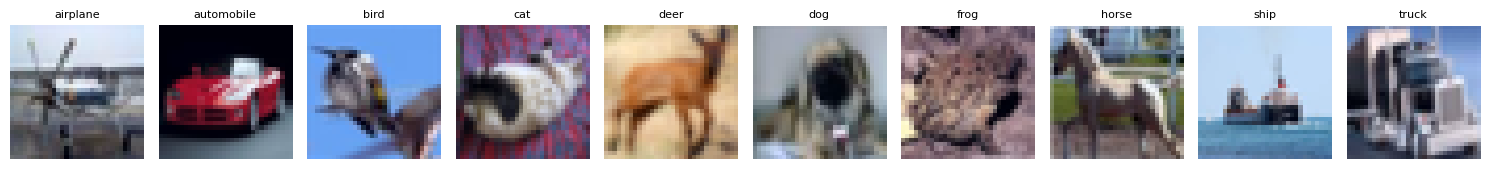

In [8]:
show_one_per_class(train_loader)

In [9]:
def train(
    # batch_size: int = 128,
    train_loader,
    test_loader,
    epochs: int = 50,
    lr: float = 2e-4,
    z_dim: int = 128,
    beta: float = 1.0,
    # data_root: str = "./data",
    device: str = None,
):
    set_seed(123)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # train_loader, test_loader = get_dataloaders(batch_size=batch_size, data_root=data_root)
    model = CVAE(z_dim=z_dim, c_dim=10).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # lists to track reconstruction + kl divergence
    train_rec_losses = []
    train_kl_losses = []
    test_rec_losses = []
    test_kl_losses = []
    def loop(loader, train_mode: bool):
        model.train(train_mode)
        tot_loss = tot_rec = tot_kl = n = 0
        for x, y in loader:
            x = x.to(device)           # normalized tensors
            c = one_hot(y.to(device), 10)

            if train_mode:
                opt.zero_grad()

            x_hat, mu, logvar = model(x, c)
            loss, parts = elbo_loss_mse(x_hat, x, mu, logvar, beta=beta)

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()

            b = x.size(0)
            tot_loss += loss.item() * b
            tot_rec  += parts["recon"].item() * b
            tot_kl   += parts["kl"].item() * b
            n += b
        return tot_loss / n, tot_rec / n, tot_kl / n

    for ep in range(1, epochs + 1):
        tr_loss, tr_rec, tr_kl = loop(train_loader, True)
        te_loss, te_rec, te_kl = loop(test_loader, False)
        # store only train values (or both if you want)
        train_rec_losses.append(tr_rec)
        train_kl_losses.append(tr_kl)
        # store only train values (or both if you want)
        test_rec_losses.append(te_rec)
        test_kl_losses.append(te_kl)
        print(f"Epoch {ep:03d} | "
              f"train {tr_loss:.4f} (rec {tr_rec:.4f}, kl {tr_kl:.4f}) | "
              f"val {te_loss:.4f} (rec {te_rec:.4f}, kl {te_kl:.4f})")

    return model,train_rec_losses,train_kl_losses,test_rec_losses,test_kl_losses

In [10]:
@torch.no_grad()
def show_recon(model, batch, use_logits=False):
    model.eval()
    x, y = batch  # x is already normalized
    x = x.to(next(model.parameters()).device)
    mu, logvar = model.encoder(x, one_hot(y, num_classes=10).to(x.device))
    z = model.reparameterize(mu, logvar)
    x_hat = model.decoder(z, one_hot(y, num_classes=10).to(x.device))

    # Map to [0,1] correctly:
    if use_logits:           # BCEWithLogitsLoss case
        x_vis = torch.sigmoid(x_hat).cpu()
    else:                    # MSE/L1 on normalized images
        x_vis = denormalize(x_hat).cpu()

    import torchvision.utils as vutils
    import matplotlib.pyplot as plt
    grid = vutils.make_grid(torch.cat([denormalize(x).cpu(), x_vis], dim=0), nrow=x.size(0))
    plt.figure(figsize=(x.size(0), 2))
    plt.imshow(grid.permute(1, 2, 0), interpolation="nearest")
    plt.axis("off"); plt.show()


In [11]:
@torch.no_grad()
def sample_grid(model: CVAE, labels, n_per_class: int = 8, out_path: str = "cifar10_cvae_samples.png", device: str = None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    labels = torch.as_tensor(labels, dtype=torch.long, device=device)
    c = one_hot(labels, num_classes=10).repeat_interleave(n_per_class, dim=0)

    z = torch.randn(len(labels) * n_per_class, model.z_dim, device=device)
    x_hat = model.decoder(z, c)  # normalized space
    x_vis = denormalize(x_hat).cpu()  # [0,1]
    print(x_hat.min().item(), x_hat.max().item())
    print(x_vis.min().item(), x_vis.max().item())
    grid = vutils.make_grid(x_vis, nrow=n_per_class, padding=2)
    vutils.save_image(grid, out_path)
    # Plot inline
    plt.figure(figsize=(n_per_class, len(labels)))  # adjust size
    plt.imshow(grid.permute(1, 2, 0))  # [C,H,W] → [H,W,C]
    plt.axis("off")
    plt.show()
    print(f"Saved samples to {out_path}")

In [13]:
@torch.no_grad()
def latent_pca_plot(model: CVAE, loader: DataLoader, device: str, out_path: str = "latent_pca.png", max_points: int = 5000):
    model.eval()
    zs, ys = [], []
    seen = 0
    for x, y in loader:
        x = x.to(device)
        c = one_hot(y.to(device), 10)
        mu, logvar = model.encoder(x, c)
        z = mu  # use mean as embedding
        zs.append(z.detach().cpu())
        ys.append(y.detach().cpu())
        seen += x.size(0)
        if seen >= max_points:
            break
    Z = torch.cat(zs, dim=0).numpy()
    Y = torch.cat(ys, dim=0).numpy()

    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z)

    plt.figure(figsize=(6,5))
    scatter = plt.scatter(Z2[:,0], Z2[:,1], c=Y, s=8, cmap="tab10")
    plt.legend(*scatter.legend_elements(), title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title("CVAE latent space (PCA to 2D)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"[viz] Saved latent PCA plot -> {out_path}")

In [19]:
model,train_rec,train_kl,test_rec,test_kl = train(
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=50,          # increase for better fidelity
    lr=1e-4,
    z_dim=512,
    beta=1.0,
)

Epoch 001 | train 1680.0380 (rec 1504.8266, kl 175.2114) | val 1200.9444 (rec 997.3736, kl 203.5708)
Epoch 002 | train 1105.9967 (rec 895.8757, kl 210.1209) | val 1013.4338 (rec 803.4663, kl 209.9675)
Epoch 003 | train 967.7888 (rec 761.8549, kl 205.9339) | val 900.2750 (rec 701.3381, kl 198.9368)
Epoch 004 | train 882.9844 (rec 685.9444, kl 197.0400) | val 834.1869 (rec 639.7508, kl 194.4361)
Epoch 005 | train 826.7664 (rec 636.5596, kl 190.2068) | val 790.2986 (rec 600.9262, kl 189.3724)
Epoch 006 | train 782.0873 (rec 596.0306, kl 186.0568) | val 757.5594 (rec 571.2106, kl 186.3488)
Epoch 007 | train 751.3282 (rec 567.5667, kl 183.7615) | val 723.9917 (rec 542.2740, kl 181.7177)
Epoch 008 | train 727.6357 (rec 545.2462, kl 182.3895) | val 702.3007 (rec 518.7961, kl 183.5046)
Epoch 009 | train 705.8810 (rec 524.0536, kl 181.8274) | val 693.8240 (rec 510.7571, kl 183.0669)
Epoch 010 | train 690.6457 (rec 508.3376, kl 182.3081) | val 676.3520 (rec 495.4125, kl 180.9394)
Epoch 011 | tra

In [22]:
torch.save(model.state_dict(), "CVAE_model_05.pth")

In [ ]:
model = CVAE(z_dim=128)# recreate the model with same architecture
model.load_state_dict(torch.load("CVAE_model.pth"))
model.eval()# set to evaluation mode if only doing inference

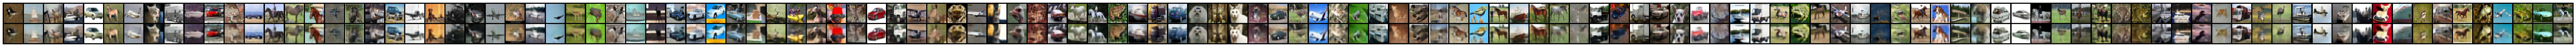

In [20]:
show_recon(model,next(iter(train_loader)))


* The **top row (originals)** look like normal CIFAR-10 images.
* The **bottom row (reconstructions)** are definitely recognizable (shapes, colors, rough textures are there), but they are **a bit blurrier / less detailed** than the originals.

That is **completely normal** for a vanilla CVAE with:

* MSE recon loss
* Simple convolutional encoder/decoder
* KL regularization

---

### Why reconstructions look blurrier

* **MSE loss** → encourages pixel-wise averaging (blurry outputs).
* **KL term** → pulls the latent distribution toward a Gaussian, reducing sharpness.
* **Decoder architecture** → relatively shallow compared to state-of-the-art generative models (no residual blocks, attention, etc.).

the model learns **semantic structure**, but not pixel-perfect detail.

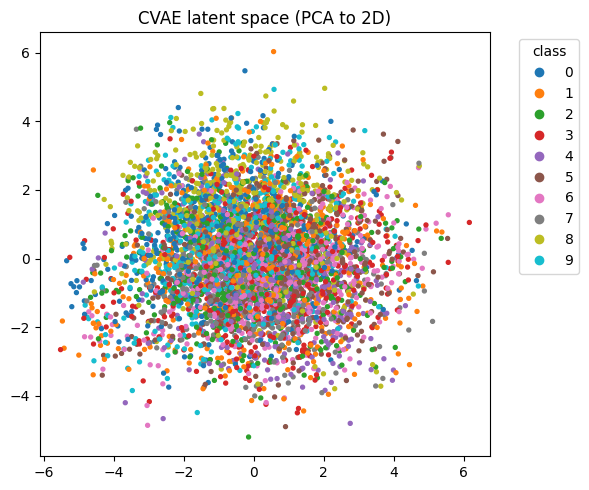

[viz] Saved latent PCA plot -> latent_pca.png


In [24]:
latent_pca_plot(model,train_loader,"cuda")

In [30]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [32]:
classes[0]

'airplane'

-3.0212769508361816 2.770378589630127
0.0 1.0


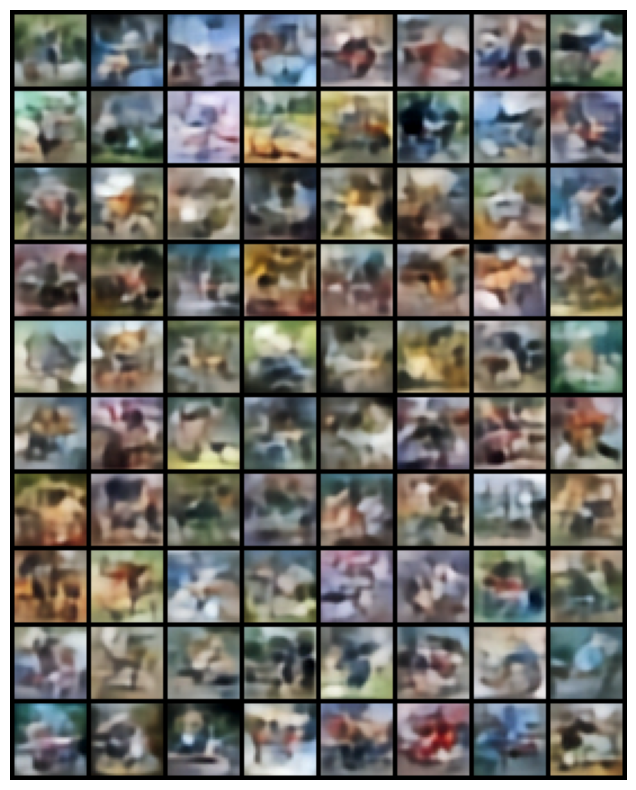

Saved samples to cifar10_cvae_samples.png


In [21]:
sample_grid(model, labels=list(range(10)), n_per_class=8, out_path="cifar10_cvae_samples.png")



* Images have **colors and textures**, but no sharp object boundaries.
* They look like **blurry collages of CIFAR-10 colors** rather than clear planes, cars, dogs, etc.

This is **completely normal for vanilla CVAEs** trained with MSE on CIFAR-10.

Here’s why:

### Why CVAE samples look blurrier than reconstructions

* **Reconstruction**: the encoder gives a good latent `z` close to the input → decoder can rebuild something close to the original.
* **Sampling**: you draw a random `z ∼ N(0,I)` → decoder has to “imagine” a plausible image just from prior + label. Unless the model is very powerful, samples collapse to “average-like” blobs.

### Specific reasons in our case

1. **MSE loss**: encourages pixel-wise averaging → blurry images.
2. **Decoder depth**: only 3 deconvolutional layers → limited capacity.
3. **KL term**: even with β < 1, it pushes latents toward Gaussian, which sacrifices fine detail.
4. **CIFAR-10**: small, diverse dataset → harder to learn crisp conditional generation with plain CVAE.

---
current **architecture + ELBO objective**, those fuzzy samples are exactly what we’d expect. Reconstructions look okay-ish, but random samples look like blurry noise with hints of CIFAR-10 structure.

